# Models and Explainability

**Themes:** Explainable AI · Responsible AI

This notebook:
1. Trains a Random Forest classifier on the anonymized HR data
2. Evaluates performance (accuracy, F1, ROC-AUC)
3. Explains predictions globally and per-employee using **SHAP**
4. Demonstrates a human-readable HR risk report

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay)
from sklearn.pipeline import Pipeline

***
## 1. Load processed data
We import the cleaned HR dataset where categories are already converted to numbers.

- We load the cleaned and preprocessed dataset that is ready for modeling.
- The dataset has already gone through data cleaning, feature engineering, and anonymization.
- Irrelevant or sensitive columns have been removed.
- All variables are formatted correctly (e.g., categorical encoded, missing values handled).

This ensures the model works with a clean DataFrame ($X$ and $y$) and ready for the machine learning algorithm.
***

In [3]:
df = pd.read_csv('../data/processed/hr_anonymized.csv')

# Target and features
TARGET = 'Termd'
# Drop any remaining non-numeric or leaky columns
DROP_COLS = [TARGET, 'TermReason', 'EmploymentStatus', 'DateofTermination',
             'LastPerformanceReview_Date', 'PositionID', 'Position']
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')
print(f'Class balance - 0: {(y==0).sum()}, 1: {(y==1).sum()}')
X.head(3)

Features: 20 | Samples: 311
Class balance - 0: 207, 1: 104


,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,MaritalDesc,CitizenDesc,Department,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,tenure_days,age_group
0,0,0,1,1,5,4,0,62506,3,2,3,5,0,4.60,5,0,0,1,4563,2
1,1,1,1,5,3,3,0,104437,1,2,2,4,1,4.96,3,6,0,17,444,-1
2,1,1,0,5,5,3,0,64955,1,2,3,5,1,3.02,3,0,0,3,447,1


***
## 2. Train/Test split

Next, we split the data into two parts: one for learning, one for testing.

- The training set is used to teach the model how to recognize patterns.
- The test set is used to check how well the model performs on new, unseen data.
- This step is important to make sure the model doesn’t just memorize the data but can actually generalize.
- Our goal is to predict whether an employee will leave (attrition).
***

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 248 samples | Test: 63 samples


***
## 3. Train Random Forest

In this part we build a decision trees to predict employee status (Termd). We train a Random Forest model to predict employee attrition.

- Instead of relying on a single decision tree, Random Forest combines many trees.
- Each tree looks at the data a bit differently and makes its own prediction.
- The final result is based on all trees working together.
- This makes the model:
    * More accurate
    * More stable
    * Less likely to overfit
***

In [5]:
rf = RandomForestClassifier(
    n_estimators=100, # Number of trees, 100 is enough for this dataset size
    max_depth=6, # Limit depth to prevent overfitting
    class_weight='balanced', # Handle class imbalance with balanced weights
    random_state=42,
    n_jobs=-1 # Use all available cores
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1] # Predict probability scores for the positive class (Termd = 1) on the test set.

print('Classification Report')
print(classification_report(y_test, y_pred, target_names=['Active', 'Terminated']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

Classification Report
              precision    recall  f1-score   support

      Active       0.98      1.00      0.99        42
  Terminated       1.00      0.95      0.98        21

    accuracy                           0.98        63
   macro avg       0.99      0.98      0.98        63
weighted avg       0.98      0.98      0.98        63

ROC-AUC: 1.000


5-fold CV ROC-AUC: 1.000 ± 0.000


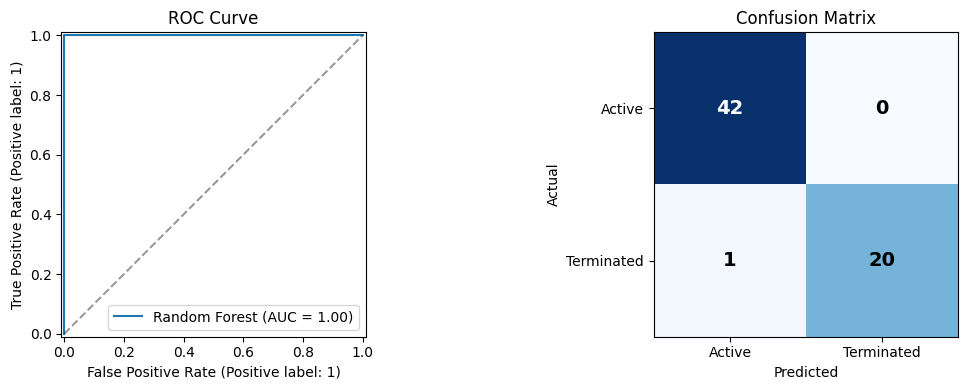

In [6]:
# Cross-validation for robust estimate
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print(f'5-fold CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name='Random Forest')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title('ROC Curve')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Active', 'Terminated'])
axes[1].set_yticklabels(['Active', 'Terminated'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black',
                     fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/model_performance.png', dpi=120, bbox_inches='tight')
plt.show()

***
## 4. SHAP Explainability

SHAP stands for SHapley Additive exPlanations.

It comes from the concept of Shapley values in Game Theory.

The idea:
- Each feature is like a player in a game
- The model prediction is the payout
- SHAP calculates how much each feature contributes to the prediction
- So for every prediction we get: $$prediction = base \: value + \sum SHAP \: values$$
***

In [7]:
# Compute SHAP values on test set
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values can be:
#   - a list [class0_2D, class1_2D]  (older shap)
#   - a 3D array of shape (n_samples, n_features, 2)  (newer shap)
if isinstance(shap_values, list):
    sv = shap_values[1]  # class 1 = attrition
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]  # class 1 = attrition
else:
    sv = shap_values

print(f"SHAP values shape: {sv.shape}")
print(f"SHAP values computed for {X_test.shape[0]} employees")

SHAP values shape: (63, 20)
SHAP values computed for 63 employees


### Global Explanation: What drives attrition overall?

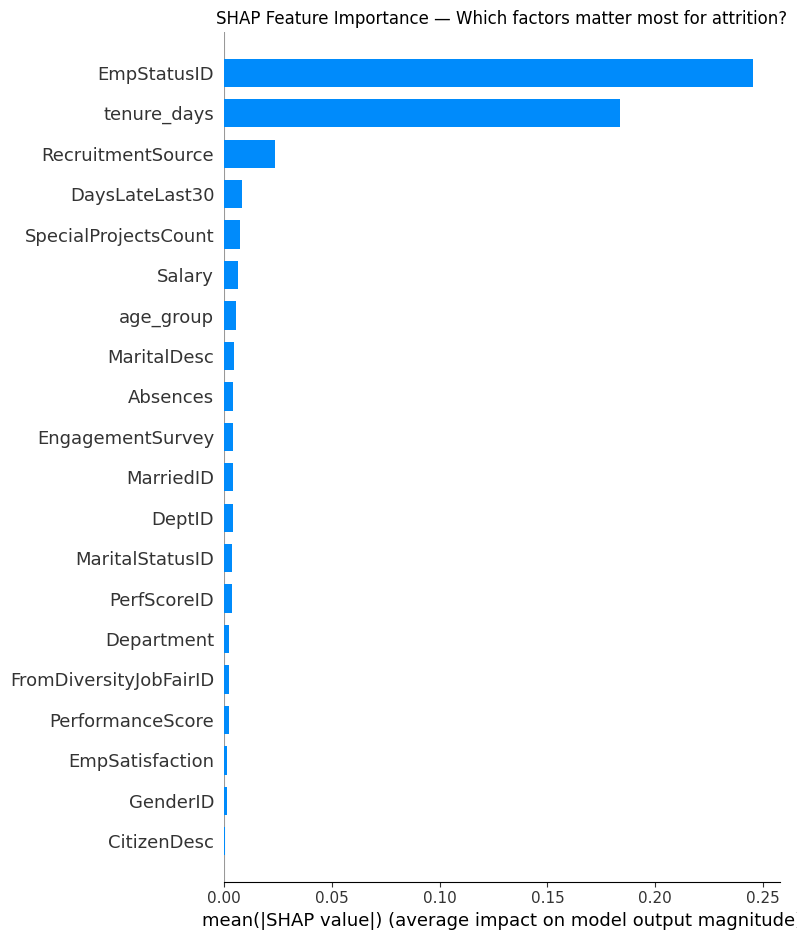

In [8]:
plt.figure(figsize=(12, 6))
shap.summary_plot(sv, X_test, plot_type="bar",
                  show=False, max_display=20)
plt.title("SHAP Feature Importance — Which factors matter most for attrition?", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/shap_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation:** bars show the average absolute SHAP value per feature.

Longer bars means stronger influence on attrition predictions.

***
### Beeswarm: direction of each feature's effect

This show how features influence the predictions of a machine learning model across the entire dataset.

A SHAP beeswarm plot shows:
- Feature importance
- Direction of impact
- Distribution of effects across all samples

It is essentially a summary plot of SHAP values.
***

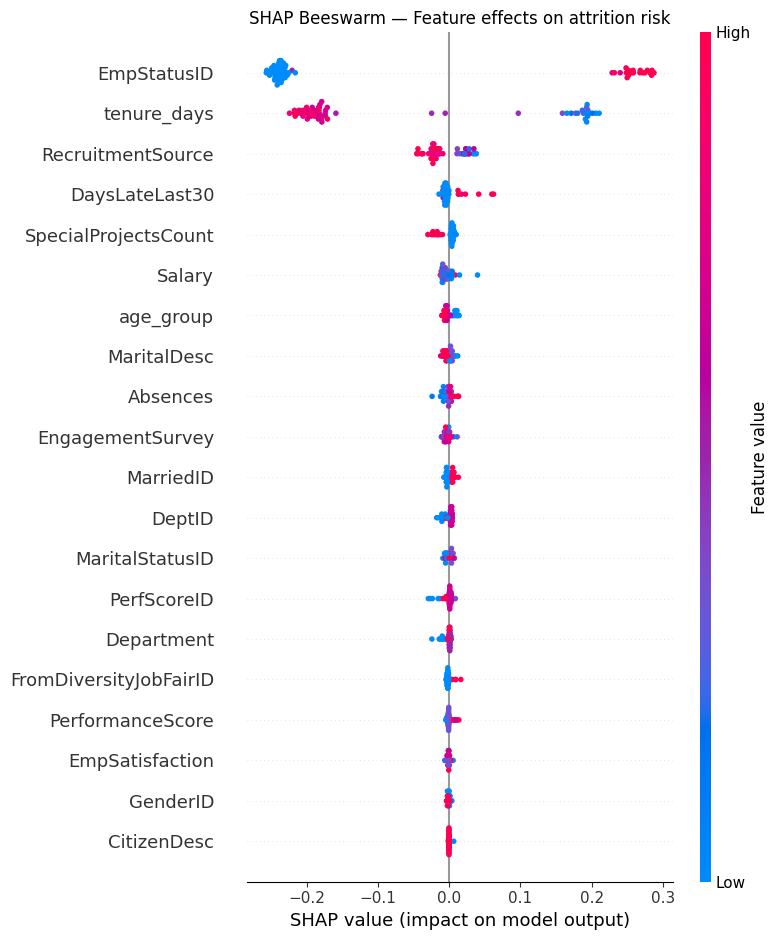

In [9]:
plt.figure(figsize=(12, 6))
shap.summary_plot(sv, X_test, show=False, max_display=20)
plt.title("SHAP Beeswarm — Feature effects on attrition risk", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation:**
- Each dot = one employee
- Red = high feature value, Blue = low feature value
- Dots pushed RIGHT increase attrition risk
- Dots pushed LEFT decrease attrition risk

***
## 5. Per-Employee Explanation (Local SHAP)

Now we zoom in on individual employees.

For each person, we can explain exactly why the model thinks they might leave.

- We can clearly see:
    * What is pushing their risk higher
    * What is keeping their risk lower
- For example:
    * Overtime → increases risk
    * Good salary → decreases risk

- This is especially useful for HR because it answers a very practical question:
 “Why is this specific employee at risk?”
***

In [10]:
def explain_employee(idx, X_test, y_test, y_proba, shap_vals, top_n=3):
    """Print a human-readable attrition risk explanation for one employee."""
    risk_score = y_proba[idx]
    actual = y_test.iloc[idx]

    if risk_score >= 0.6:
        risk_label = '🔴 HIGH'
    elif risk_score >= 0.3:
        risk_label = '🟡 MEDIUM'
    else:
        risk_label = '🟢 LOW'

    print(f'=== Employee #{X_test.index[idx]} ===')
    print(f'Attrition risk:  {risk_label} ({risk_score:.1%})')
    print(f'Actual outcome:  {"Terminated" if actual == 1 else "Active"}')
    print()

    # Top contributing SHAP factors
    emp_shap = pd.Series(shap_vals[idx], index=X_test.columns)
    top_pos = emp_shap.nlargest(top_n)   # factors INCREASING risk
    top_neg = emp_shap.nsmallest(top_n)  # factors DECREASING risk

    print(f'Top {top_n} risk-INCREASING factors:')
    for feat, val in top_pos.items():
        feat_val = X_test.iloc[idx][feat]
        print(f'  ↑ {feat} = {feat_val:.2f}  (SHAP: +{val:.3f})')

    print(f'\nTop {top_n} risk-DECREASING factors:')
    for feat, val in top_neg.items():
        feat_val = X_test.iloc[idx][feat]
        print(f'  ↓ {feat} = {feat_val:.2f}  (SHAP: {val:.3f})')

    print()
    return risk_score

# Find the highest-risk employee in the test set and explain them
highest_risk_idx = np.argmax(y_proba)
explain_employee(highest_risk_idx, X_test, y_test, y_proba, sv)

=== Employee #89 ===
Attrition risk:  🔴 HIGH (99.5%)
Actual outcome:  Terminated

Top 3 risk-INCREASING factors:
  ↑ EmpStatusID = 5.00  (SHAP: +0.249)
  ↑ tenure_days = 1653.00  (SHAP: +0.188)
  ↑ RecruitmentSource = 3.00  (SHAP: +0.023)

Top 3 risk-DECREASING factors:
  ↓ DaysLateLast30 = 0.00  (SHAP: -0.002)
  ↓ FromDiversityJobFairID = 0.00  (SHAP: -0.001)
  ↓ PerformanceScore = 1.00  (SHAP: -0.001)



np.float64(0.9945850607687872)

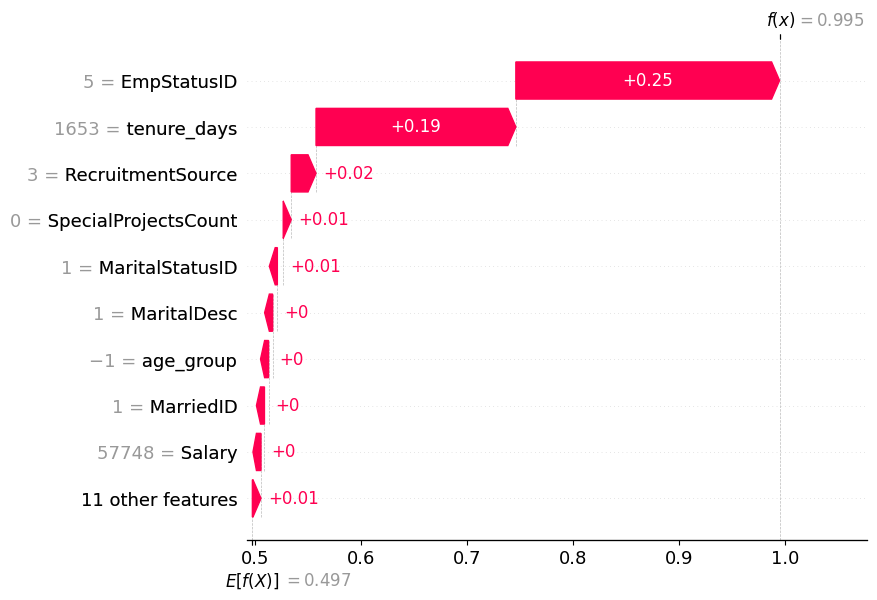

In [11]:
# Waterfall plot for the highest-risk employee (visual explanation)
exp_val = explainer.expected_value
if isinstance(exp_val, (list, np.ndarray)):
    base_val = exp_val[1]  # class 1
else:
    base_val = exp_val

shap.plots.waterfall(
    shap.Explanation(
        values=sv[highest_risk_idx],
        base_values=base_val,
        data=X_test.iloc[highest_risk_idx].values,
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.savefig("../docs/shap_waterfall_example.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation:** each bar shows how a single feature pushed this employee's prediction up (red) or down (blue) from the base rate.

***
## 6. HR Risk Dashboard (All Employees)

Finally, everything is brought together into a dashboard for HR.

- Each employee gets a risk score.
- The key reasons behind that score are also shown.
- This allows HR teams to:
    * Quickly spot high-risk employees
    * Take action early (adjust workload, improve conditions, etc.)

Overall, this turns raw data into clear, actionable insights that help reduce employee turnover.
***

In [12]:
# Build a risk summary table for HR
risk_df = X_test.copy()
risk_df['attrition_risk_score'] = y_proba
risk_df['risk_label'] = pd.cut(
    risk_df['attrition_risk_score'],
    bins=[-0.001, 0.3, 0.6, 1.001],
    labels=['Low', 'Medium', 'High']
)
risk_df['actual_termd'] = y_test.values

# Top SHAP factor per employee
top_factors = []
for i in range(len(X_test)):
    emp_shap = pd.Series(sv[i], index=X_test.columns)
    top_factor = emp_shap.abs().idxmax()
    top_factors.append(top_factor)
risk_df['top_shap_factor'] = top_factors

# Summary by risk level
print('=== HR Risk Summary ===')
print(risk_df['risk_label'].value_counts())
print()

print('=== High-Risk Employees (sample) ===')
high_risk = risk_df[risk_df['risk_label'] == 'High'].sort_values(
    'attrition_risk_score', ascending=False
)
print(high_risk[['attrition_risk_score', 'risk_label', 'top_shap_factor']].head(10))

# Save
risk_df.to_csv('../data/processed/hr_risk_predictions.csv', index=True)
print('\nSaved: hr_risk_predictions.csv ✓')

=== HR Risk Summary ===
risk_label
Low       42
High      20
Medium     1
Name: count, dtype: int64

=== High-Risk Employees (sample) ===
     attrition_risk_score risk_label top_shap_factor
89               0.994585       High     EmpStatusID
151              0.993379       High     EmpStatusID
302              0.989283       High     EmpStatusID
233              0.984446       High     EmpStatusID
221              0.970659       High     EmpStatusID
303              0.961787       High     EmpStatusID
50               0.950571       High     EmpStatusID
185              0.948642       High     EmpStatusID
280              0.943822       High     EmpStatusID
27               0.940657       High     EmpStatusID

Saved: hr_risk_predictions.csv ✓


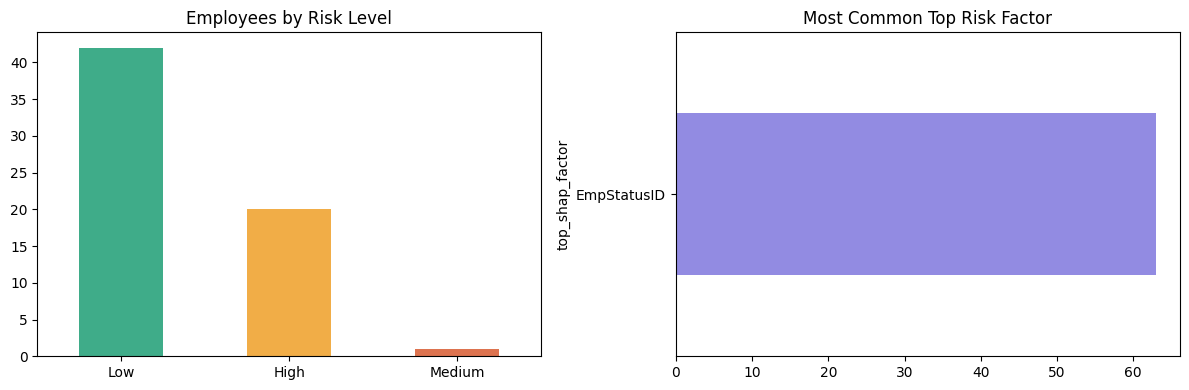


✅ Model + Explainability complete. Ready for 03_frugal.ipynb


In [13]:
# Risk distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

risk_df['risk_label'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#1D9E75', '#EF9F27', '#D85A30'], alpha=0.85
)
axes[0].set_title('Employees by Risk Level')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)

risk_df['top_shap_factor'].value_counts().head(8).plot(
    kind='barh', ax=axes[1], color='#7F77DD', alpha=0.85
)
axes[1].set_title('Most Common Top Risk Factor')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../docs/hr_risk_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n✅ Model + Explainability complete. Ready for 03_frugal.ipynb')